In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [12]:
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=10,
    random_state=42
)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val   = torch.tensor(X_val, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_val   = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
y_test  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)


In [13]:
class MLP(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(20, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

In [14]:
class EarlyStopping:
    def __init__(self, patience=10):
        self.patience = patience
        self.best_loss = float("inf")
        self.counter = 0
        self.stop = False

    def step(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

In [15]:
def train_model(model, optimizer, criterion,
                X_train, y_train, X_val, y_val,
                epochs=100, l1_lambda=0.0, early_stopper=None):

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        logits = model(X_train)
        loss = criterion(logits, y_train)

        # 🔴 L1 REGULARIZATION (MANUAL)
        if l1_lambda > 0:
            l1_penalty = sum(p.abs().sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_penalty

        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_loss = criterion(val_logits, y_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        if early_stopper:
            early_stopper.step(val_loss.item())
            if early_stopper.stop:
                break

    return train_losses, val_losses

In [16]:
experiments = [
    {"name": "No_Regularization", "dropout": 0.0, "l1": 0.0,  "l2": 0.0,   "early": False},
    {"name": "L2_Regularization", "dropout": 0.0, "l1": 0.0,  "l2": 1e-3,  "early": False},
    {"name": "L1_Regularization", "dropout": 0.0, "l1": 1e-4, "l2": 0.0,   "early": False},
    {"name": "Dropout",           "dropout": 0.5, "l1": 0.0,  "l2": 0.0,   "early": False},
    {"name": "Early_Stopping",    "dropout": 0.0, "l1": 0.0,  "l2": 0.0,   "early": True},
]

In [17]:
criterion = nn.BCEWithLogitsLoss()

results = []
histories = {}

for exp in experiments:
    model = MLP(dropout=exp["dropout"])

    optimizer = optim.AdamW(
        model.parameters(),
        lr=1e-3,
        weight_decay=exp["l2"]  # 🔴 L2 REGULARIZATION
    )

    early_stopper = EarlyStopping(patience=10) if exp["early"] else None

    train_loss, val_loss = train_model(
        model, optimizer, criterion,
        X_train, y_train, X_val, y_val,
        l1_lambda=exp["l1"],          # 🔴 L1 REGULARIZATION
        early_stopper=early_stopper
    )

    with torch.no_grad():
        preds = torch.sigmoid(model(X_test))
        test_acc = ((preds > 0.5) == y_test).float().mean().item()

    torch.save(model.state_dict(), f"{exp['name']}.pt")

    histories[exp["name"]] = (train_loss, val_loss)

    results.append({
        "Model": exp["name"],
        "Final_Train_Loss": train_loss[-1],
        "Final_Val_Loss": val_loss[-1],
        "Test_Accuracy": test_acc
    })

In [18]:
df = pd.DataFrame(results)
df

,Model,Final_Train_Loss,Final_Val_Loss,Test_Accuracy
0,No_Regularization,0.111795,0.228230,0.933333
1,L2_Regularization,0.128218,0.232154,0.933333
2,L1_Regularization,0.177526,0.248252,0.920000
3,Dropout,0.255181,0.313355,0.906667
4,Early_Stopping,0.119290,0.241810,0.946667


In [19]:
df.to_csv("metrics.csv", index=False)

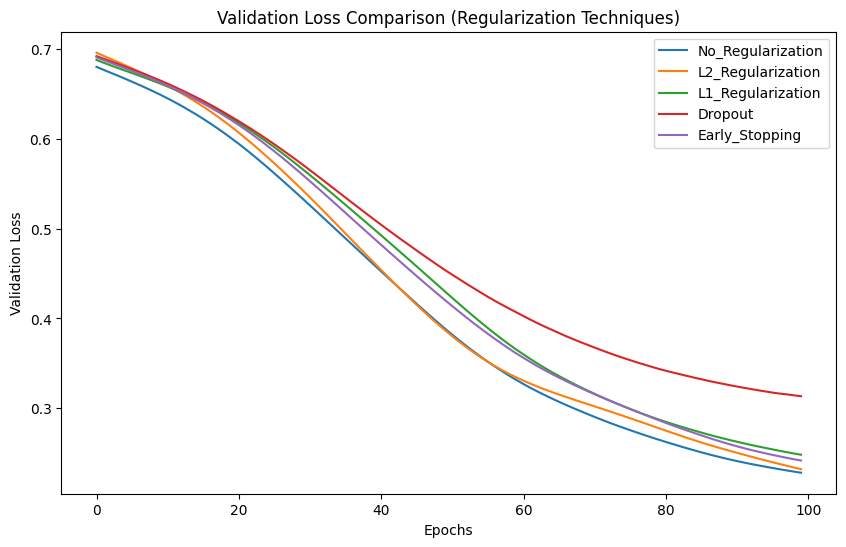

In [20]:
plt.figure(figsize=(10,6))

for name, (train_l, val_l) in histories.items():
    plt.plot(val_l, label=name)

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison (Regularization Techniques)")
plt.legend()
plt.show()